# COSC 2671 — Assignment 2
## Do Polarized Emotional Communities Form Around AI Job Replacement Discussions on YouTube, and Who Are the Influential Users Shaping These Communities?

**Data Sources:** YouTube (Data API v3) + Bluesky (AT Protocol)  
**Nodes:** Individual users (commenters / posters)  
**Edges:** Directed reply relationships — A → B means A replied to B  
**Network type:** Directed, weighted (weight = number of replies between users)  

### Research Question
Do polarized emotional communities form around AI job replacement discussions on YouTube (and Bluesky), and who are the influential users shaping these communities?



## STEP 0 — Install & Import

In [ ]:

import subprocess, sys
pkgs = ['vaderSentiment','python-louvain','textblob','google-api-python-client','scipy']
for p in pkgs:
    subprocess.run([sys.executable,'-m','pip','install',p,'--quiet'], check=False)

import os, re, time, warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from collections import Counter, defaultdict
from datetime import datetime
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

try:
    import community as community_louvain
except ImportError:
    from community import community_louvain

for d in ['stopwords','punkt','wordnet','punkt_tab']:
    nltk.download(d, quiet=True)

print(' All imports successful')

 All imports successful


## STEP 1 — Configuration

In [ ]:

#
YOUTUBE_API_KEY = os.environ.get('YOUTUBE_API_KEY', 'place_api_key_here')
BSKY_HANDLE     = os.environ.get('BSKY_HANDLE',     'place handle_here')
BSKY_APP_PASS   = os.environ.get('BSKY_APP_PASS',   'place_password_here')

if not YOUTUBE_API_KEY:
    print('WARNING: YOUTUBE_API_KEY not set — will use cached sample_data/ if available')
else:
    print('YouTube API key loaded (value hidden for security)')

SEARCH_QUERIES = [
    'AI replacing jobs',
    'artificial intelligence job loss',
    'automation unemployment',
    'AI taking over jobs',
    'robots replace workers'
]

MAX_VIDEOS             = 20
MAX_COMMENTS_PER_VIDEO = 300
MAX_BSKY_POSTS         = 1000
N_TOPICS               = 5

#
NETWORK_SAMPLE_SIZE = 2000
RANDOM_SEED         = 42

DATA_DIR   = 'sample_data'
OUTPUT_DIR = 'outputs'
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Config loaded')


YouTube API key loaded (value hidden for security)
Config loaded


## STEP 2 — Data Collection

In [ ]:
from data_collection.youtube_collector import YouTubeCollector

yt_videos_path   = os.path.join(DATA_DIR, 'youtube_videos.csv')
yt_comments_path = os.path.join(DATA_DIR, 'youtube_comments.csv')

if os.path.exists(yt_comments_path):
    print('Loading cached YouTube data (delete CSVs to re-collect)')
    df_yt_videos   = pd.read_csv(yt_videos_path)
    df_yt_comments = pd.read_csv(yt_comments_path)
elif YOUTUBE_API_KEY:
    yt = YouTubeCollector(api_key=YOUTUBE_API_KEY)
    
    df_yt_videos, df_yt_comments = yt.collect(
        queries=SEARCH_QUERIES,
        max_videos=MAX_VIDEOS,
        max_comments=MAX_COMMENTS_PER_VIDEO,
        network_sample_size=NETWORK_SAMPLE_SIZE,
        random_seed=RANDOM_SEED,
    )
    df_yt_videos.to_csv(yt_videos_path, index=False)
    df_yt_comments.to_csv(yt_comments_path, index=False)
else:
    print('No API key and no cached data. Using built-in sample_data/ files.')
    df_yt_videos   = pd.read_csv(os.path.join(DATA_DIR, 'youtube_videos.csv'))
    df_yt_comments = pd.read_csv(os.path.join(DATA_DIR, 'youtube_comments.csv'))

print(f'YouTube: {len(df_yt_videos)} videos, {len(df_yt_comments)} comments')
df_yt_comments.head(2)


Loading cached YouTube data (delete CSVs to re-collect)
YouTube: 77 videos, 10100 comments


,comment_id,video_id,text,author_name,author_id,like_count,published_at,is_reply,parent_id,parent_author_id,collected_at
0,UgwrzkMakRZKcsgGHIN4AaABAg.9u_3SE_5D_g9u_W0sacoO2,dRPNp7mcAMI,big side eye,@amelialeahh,UCREPTgIduwDcvYHqfRJ61BQ,2896,2023-09-12T22:59:49Z,True,UgwrzkMakRZKcsgGHIN4AaABAg,UC6aEjiaunlGB74q64lxT5kg,2026-05-25T06:52:26.624780
1,UgwrzkMakRZKcsgGHIN4AaABAg.9u_3SE_5D_g9u_fgwX1X6R,dRPNp7mcAMI,Ikr,@Ariellaslay603,UC7Yiuzumbo6r-z4JGpK71Sw,293,2023-09-13T00:33:05Z,True,UgwrzkMakRZKcsgGHIN4AaABAg,UC6aEjiaunlGB74q64lxT5kg,2026-05-25T06:52:26.624780


In [ ]:
#  Bluesky collector 
from data_collection.bluesky_collector import BlueskyCollector

bsky_posts_path = os.path.join(DATA_DIR, 'bluesky_posts.csv')

if os.path.exists(bsky_posts_path):
    print('Loading cached Bluesky data')
    df_bsky = pd.read_csv(bsky_posts_path)
else:
    bsky = BlueskyCollector(handle=BSKY_HANDLE, app_password=BSKY_APP_PASS)
    df_bsky = bsky.collect(queries=SEARCH_QUERIES, max_posts=MAX_BSKY_POSTS)
    df_bsky.to_csv(bsky_posts_path, index=False)

print(f'Bluesky → {len(df_bsky)} posts')
df_bsky.head(2)

Loading cached Bluesky data
Bluesky → 873 posts


,uri,cid,author_handle,author_did,author_display,text,created_at,like_count,reply_count,repost_count,reply_to_uri,reply_to_handle,mentions,is_reply,query,collected_at
0,at://did:plc:ywifce7puq7dhncuuq6nys2k/app.bsky...,bafyreidszhomsypeiahtuwvfrxh5vqvyfe7hsvfu3aksk...,drmikewatts.bsky.social,did:plc:ywifce7puq7dhncuuq6nys2k,DrMikeWatts,Replacing public servants with #AI is going to...,2026-05-25T01:59:36.945Z,1,0,0,NaN,NaN,NaN,False,AI replacing jobs,2026-05-25T06:53:33.418187
1,at://did:plc:74mleucoxbdj6y5nbyzgxjii/app.bsky...,bafyreiatkl5tmcdmgqhx5ozcnwbn2zeulekfdfmgo5cg5...,chemtrailhaze.bsky.social,did:plc:74mleucoxbdj6y5nbyzgxjii,frilled lizard metareptile,my biggest concern with the idea of AI replaci...,2026-05-24T23:54:00.327Z,5,1,0,NaN,NaN,NaN,False,AI replacing jobs,2026-05-25T06:53:33.418187


In [ ]:
#  Dataset overview 
print('=== DATASET OVERVIEW ===')
print(f'YouTube comments : {len(df_yt_comments):,}')
print(f'- with replies : {df_yt_comments["is_reply"].sum():,}')
print(f'- unique users : {df_yt_comments["author_id"].nunique():,}')
print(f'Bluesky posts: {len(df_bsky):,}')
print(f'- with replies : {df_bsky["is_reply"].sum():,}')
print(f'- unique users : {df_bsky["author_handle"].nunique():,}')
print()
print('Network suitability check:')
print(f'YouTube reply edges available: {df_yt_comments["is_reply"].sum() > 0}')
print(f'Bluesky reply edges available: {df_bsky["is_reply"].sum() > 0}')
print(f'Text data for NLP: YES (comment/post text in both datasets)')

=== DATASET OVERVIEW ===
YouTube comments : 10,100
- with replies : 10,100
- unique users : 7,125
Bluesky posts: 873
- with replies : 358
- unique users : 761

Network suitability check:
YouTube reply edges available: True
Bluesky reply edges available: True
Text data for NLP: YES (comment/post text in both datasets)


## STEP 3 — NLP Analysis

In [ ]:
#  Text preprocessing 
from nlp_analysis.preprocessor import TextPreprocessor
prep = TextPreprocessor()

df_yt_comments['clean_text']= df_yt_comments['text'].apply(prep.clean)
df_bsky['clean_text']= df_bsky['text'].apply(prep.clean)
print(' Text cleaning complete')
print(f'Sample: "{df_yt_comments["text"].iloc[0][:60]}"')
print(f'Cleaned: "{df_yt_comments["clean_text"].iloc[0][:60]}"')

 Text cleaning complete
Sample: "big side eye"
Cleaned: "big side eye"


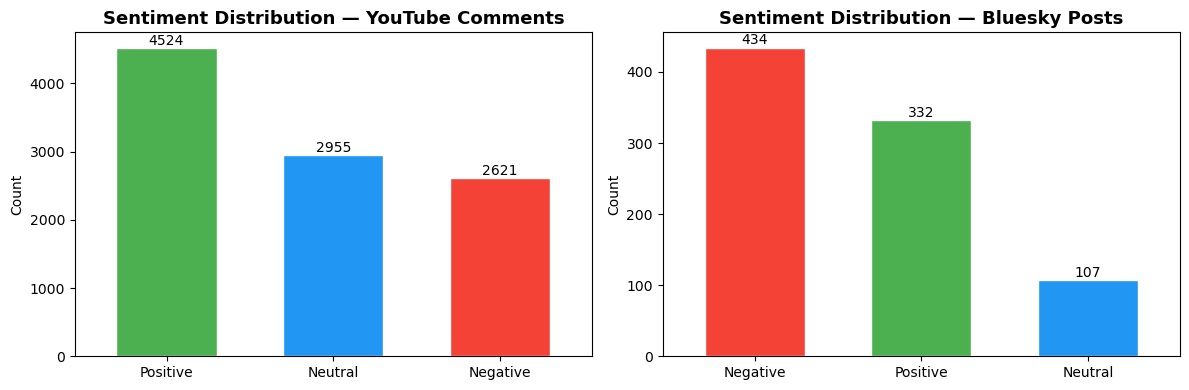

YouTube: Positive=44.8%  Negative=26.0%  Neutral=29.3%  σ=0.461
Bluesky: Positive=38.0%  Negative=49.7%  Neutral=12.3%  σ=0.513


In [ ]:
#  VADER Sentiment Analysis 
# VADER is chosen because it handles social media text well:
# capitalisation, punctuation, emojis, and slang are all considered.
from nlp_analysis.sentiment import SentimentAnalyser
sa = SentimentAnalyser()

df_yt_comments= sa.analyse(df_yt_comments, text_col='text')
df_bsky= sa.analyse(df_bsky,        text_col='text')

#  Plot sentiment distribution 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {'Positive':'#4CAF50','Neutral':'#2196F3','Negative':'#F44336'}
for ax, (df, title) in zip(axes, [
        (df_yt_comments, 'YouTube Comments'),
        (df_bsky,        'Bluesky Posts')]):
    counts = df['sentiment_label'].value_counts()
    counts.plot(kind='bar', ax=ax,color=[colors.get(l,'grey') for l in counts.index],
                edgecolor='white', width=0.6)
    ax.set_title(f'Sentiment Distribution — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig1_sentiment_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
for label, df in [('YouTube', df_yt_comments), ('Bluesky', df_bsky)]:
    pos = (df['sentiment_label']=='Positive').mean()
    neg = (df['sentiment_label']=='Negative').mean()
    neu = (df['sentiment_label']=='Neutral').mean()
    print(f'{label}: Positive={pos:.1%}  Negative={neg:.1%}  Neutral={neu:.1%}  σ={df["compound"].std():.3f}')

=== LDA VALIDATION (train 80% / test 20%) ===
YouTube  perplexity: 3732.61
Bluesky  perplexity: 5771.32
  (Lower = better generalisation to unseen text)

=== YouTube Topics ===
  0: company | way | system | lot | day | future | money | mean | thing | using
  1: robot | need | thing | something | machine | right | actually | always | video | long
  2: good | much | new | everyone | point | use | every | life | thanks | sure
  3: money | pay | need | never | want | back | rich | tax | worker | cost
  4: human | year | time | take | replace | robot | yes | world | real | want

=== Bluesky Topics ===
  0: taking | replacing | collar | white | human | layoff | company | white collar | value | good
  1: million | billion | worker | company | bezos | robot | jeff bezos | jeff | replace | bernie
  2: replacing | worker | human | need | data | replace | system | robot | buy | tax
  3: robot | worker | replace | replace worker | worker robot | robot replace | tax | amazon | musk | human
  4: aut

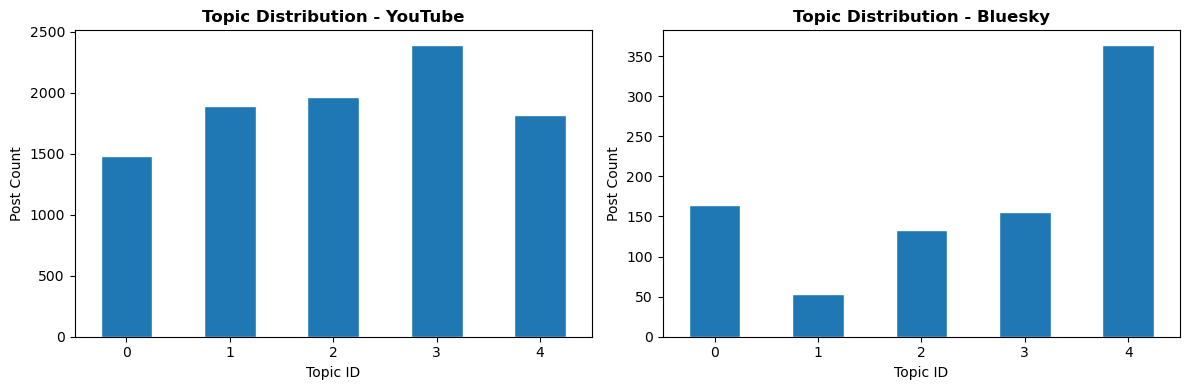

In [ ]:
#  LDA Topic Modelling with train/test perplexity validation (Gap 4 fix) 
# Perplexity measures how well the model generalises to unseen text.
# We fit on 80% train, score on 20% held-out test. Lower = better.
from nlp_analysis.topic_modeller import TopicModeller
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer as CV
from sklearn.decomposition import LatentDirichletAllocation as LDA

def validate_lda(texts, n_topics=5, test_size=0.2, random_state=42):
    texts = [t for t in texts if isinstance(t, str) and t.strip()]
    if len(texts) < n_topics * 4:
        print(f'  Too few docs ({len(texts)}) for train/test split')
        return None
    train_texts, test_texts = train_test_split(
        texts, test_size=test_size, random_state=random_state)
    vec = CV(max_df=0.95, min_df=2, max_features=3000)
    X_train = vec.fit_transform(train_texts)
    X_test  = vec.transform(test_texts)
    lda = LDA(n_components=n_topics, random_state=random_state,
              learning_method='online', max_iter=15)
    lda.fit(X_train)
    return lda.perplexity(X_test)

print('=== LDA VALIDATION (train 80% / test 20%) ===')
p_yt= validate_lda(df_yt_comments['clean_text'].tolist(), N_TOPICS, random_state=RANDOM_SEED)
p_bsky= validate_lda(df_bsky['clean_text'].tolist(),N_TOPICS, random_state=RANDOM_SEED)
if p_yt:print(f'YouTube  perplexity: {p_yt:.2f}')
if p_bsky:print(f'Bluesky  perplexity: {p_bsky:.2f}')
print('  (Lower = better generalisation to unseen text)')
print()

# Fit full model for topic assignment
tm_yt= TopicModeller(n_topics=N_TOPICS)
tm_bsky = TopicModeller(n_topics=N_TOPICS)
df_yt_comments, yt_topics   = tm_yt.fit_transform(df_yt_comments,  text_col='clean_text', prefix='yt')
df_bsky,bsky_topics = tm_bsky.fit_transform(df_bsky,text_col='clean_text', prefix='bsky')

print('=== YouTube Topics ==='); [print(f'  {k}: {v}') for k,v in yt_topics.items()]
print('\n=== Bluesky Topics ==='); [print(f'  {k}: {v}') for k,v in bsky_topics.items()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df, col, label) in zip(axes,[(df_yt_comments,'yt_dominant_topic','YouTube'),
        (df_bsky,'bsky_dominant_topic','Bluesky')]):
    vc = df[col][df[col]>=0].value_counts().sort_index()
    vc.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
    ax.set_title(f'Topic Distribution - {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Topic ID'); ax.set_ylabel('Post Count')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig2_topic_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Polarisation = std-dev of compound sentiment scores within a community
# High std-dev → polarised; low std-dev → consensus

yt_pol= df_yt_comments['compound'].std()
bsky_pol = df_bsky['compound'].std()

print(f'YouTube  Polarisation Index (σ of compound): {yt_pol:.4f}')
print(f'Bluesky  Polarisation Index (σ of compound): {bsky_pol:.4f}')

# Bimodality check: positive vs negative ratio
for label, df in [('YouTube', df_yt_comments), ('Bluesky', df_bsky)]:
    pos= (df['sentiment_label']=='Positive').sum()
    neg= (df['sentiment_label']=='Negative').sum()
    neu= (df['sentiment_label']=='Neutral').sum()
    total = len(df)
    print(f'\n{label}: Pos={pos/total:.1%}  Neg={neg/total:.1%}  Neu={neu/total:.1%}')
    

YouTube  Polarisation Index (σ of compound): 0.4607
Bluesky  Polarisation Index (σ of compound): 0.5133

YouTube: Pos=44.8%  Neg=26.0%  Neu=29.3%

Bluesky: Pos=38.0%  Neg=49.7%  Neu=12.3%


## STEP 4 — Network Construction

**Network design decisions:**
- **Nodes** = individual users (identified by YouTube channel ID / Bluesky handle)
- **Edges** = directed reply: an edge A → B means user A replied to user B's comment
- **Directed** because replies have a clear direction (sender → receiver)
- **Weighted** because multiple replies between the same users indicate stronger interaction
- **Filtering**: self-loops removed; users with ID 'unknown' excluded

In [ ]:
from network_analysis.graph_builder import build_youtube_reply_graph, build_bluesky_reply_graph

G_yt= build_youtube_reply_graph(df_yt_comments)
G_bsky = build_bluesky_reply_graph(df_bsky)

print('=== NETWORK PROPERTIES ===')
for label, G in [('YouTube', G_yt), ('Bluesky', G_bsky)]:
    print(f'\n{label}:')
    print(f'Nodes (users): {G.number_of_nodes()}')
    print(f'Edges (replies): {G.number_of_edges()}')
    print(f'Directed: {G.is_directed()}')
    print(f'  Weighted: YES (weight = reply count)')
    if G.number_of_edges() > 0:
        weights = [d['weight'] for _,_,d in G.edges(data=True)]
        print(f'Weight range: {min(weights)}–{max(weights)}')

   YouTube graph built:
     Nodes (users)   : 9808
     Edges (replies) : 8830
     Dropped — null author  : 0/10100
     Dropped — self-loop    : 657/10100
     Dropped — low weight   : 0 edges (min_weight=1)
   Bluesky graph built:
     Nodes (users)   : 51
     Edges (replies+mentions): 36
     Reply edges added  : 13
     Mention edges added: 23
     Dropped — null author  : 0 rows
     Dropped — low weight   : 0 edges (min_weight=1)
=== NETWORK PROPERTIES ===

YouTube:
Nodes (users): 9808
Edges (replies): 8830
Directed: True
  Weighted: YES (weight = reply count)
Weight range: 1–4

Bluesky:
Nodes (users): 51
Edges (replies): 36
Directed: True
  Weighted: YES (weight = reply count)
Weight range: 1–1


## STEP 5 — Network Analysis (PG COSC 2671 Requirement)

We compute multiple centrality measures to understand different aspects of influence:
- **In-degree**: how many users reply TO this person → popularity/authority signal  
- **Betweenness**: how often this user lies on paths between others → bridge/broker role  
- **PageRank**: recursive influence (being cited by influential users matters more)  
- **Eigenvector**: connection quality — linked to other high-influence nodes  
- **HITS Hub/Authority**: hub=points to good content; authority=pointed to by good hubs

In [ ]:
from network_analysis.centrality import compute_centrality

df_cent_yt= compute_centrality(G_yt,   label='YouTube')
df_cent_bsky  =compute_centrality(G_bsky, label='Bluesky')

print('\n=== TOP 15 INFLUENTIAL USERS — YouTube (ranked by PageRank) ===')
top_yt = df_cent_yt.sort_values('pagerank', ascending=False).head(15)
print(top_yt[['node','pagerank','betweenness','in_degree_raw','authority_score']]
      .rename(columns={'node':'User','pagerank':'PageRank','betweenness':'Betweenness','in_degree_raw':'Replies_Received','authority_score':'Authority'})
      .to_string(index=False))

print('\n=== TOP 15 INFLUENTIAL USERS — Bluesky (ranked by PageRank) ===')
top_bsky = df_cent_bsky.sort_values('pagerank', ascending=False).head(15)
print(top_bsky[['node','pagerank','betweenness','in_degree_raw','authority_score']]
      .rename(columns={'node':'User','pagerank':'PageRank','betweenness':'Betweenness',
                       'in_degree_raw':'Replies_Received','authority_score':'Authority'})
      .to_string(index=False))

  Computing centrality for YouTube (9808 nodes)...
   Centrality done for YouTube.
   Computing centrality for Bluesky (51 nodes)...
   Centrality done for Bluesky.

=== TOP 15 INFLUENTIAL USERS — YouTube (ranked by PageRank) ===
                    User  PageRank  Betweenness  Replies_Received     Authority
UCc8q4B1bj-668LMHyNXnTxQ  0.000818          0.0                10  3.694380e-10
UCecQeOekHKpr8GCTr5rejTw  0.000733          0.0                 5 -8.632668e-20
UCZUjCGPALjbumGdSoxdIhrw  0.000688          0.0                 5  6.763515e-20
UC7QyBFmQN6CnnJFJ-R5vhFA  0.000657          0.0                 5  2.281901e-20
UC9-VDdnNk8K_hfrqw-nwAlw  0.000656          0.0                 7 -5.249944e-20
UC9Xjq4nHCoBJF76-y_EKUHw  0.000649          0.0                 5 -2.443236e-20
UCoPutfg6DA5NNhmG5eybLhQ  0.000600          0.0                10  5.047494e-21
UCN5zgUMf3dXwWQ1I7tf4WiQ  0.000600          0.0                10  2.067795e-19
UCVwq8cAOTABAti58Eg21aAQ  0.000564          0.0   

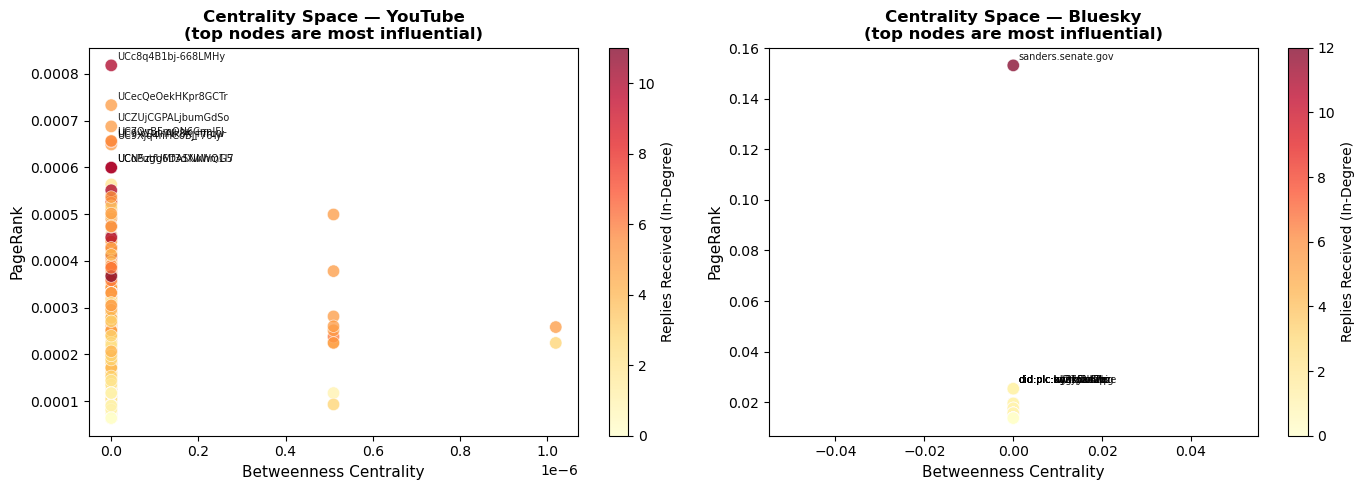

Interpretation: top-right = high betweenness + high PageRank = Bridge influencer


In [ ]:
#  Centrality visualisation: Betweenness vs PageRank coloured by in-degree ─
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df_c, title) in zip(axes,[
        (df_cent_yt,'YouTube'),
        (df_cent_bsky,'Bluesky')]):
    if df_c.empty:
        ax.text(0.5,0.5,'No data',ha='center',va='center'); continue
    sc = ax.scatter(df_c['betweenness'], df_c['pagerank'],c=df_c['in_degree_raw'], cmap='YlOrRd',s=80, alpha=0.75, edgecolors='white', linewidths=0.5)
    plt.colorbar(sc, ax=ax, label='Replies Received (In-Degree)')
    ax.set_xlabel('Betweenness Centrality', fontsize=11)
    ax.set_ylabel('PageRank', fontsize=11)
    ax.set_title(f'Centrality Space — {title}\n(top nodes are most influential)', fontsize=12, fontweight='bold')
    # Label top 8 by PageRank
    top8 = df_c.nlargest(8,'pagerank')
    for _, row in top8.iterrows():
        ax.annotate(str(row['node'])[:18],
                    (row['betweenness'], row['pagerank']),
                    fontsize=7, alpha=0.9,
                    xytext=(4,4), textcoords='offset points')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig3_centrality_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Interpretation: top-right = high betweenness + high PageRank = Bridge influencer')

In [ ]:
#  Community Detection (Louvain) 
# Louvain maximises modularity Q — groups users who interact with each other
# more than with the rest of the network.
from network_analysis.community_detector import detect_communities

G_yt,   partition_yt   = detect_communities(G_yt,   label='YouTube')
G_bsky, partition_bsky = detect_communities(G_bsky, label='Bluesky')

df_cent_yt['community']   = df_cent_yt['node'].map(partition_yt)
df_cent_bsky['community'] = df_cent_bsky['node'].map(partition_bsky)

n_comm_yt   = len(set(partition_yt.values()))   if partition_yt   else 0
n_comm_bsky = len(set(partition_bsky.values())) if partition_bsky else 0
print(f'Communities detected — YouTube: {n_comm_yt}, Bluesky: {n_comm_bsky}')

   YouTube: 1293 communities detected  (modularity Q = 0.9781)
   Bluesky: 15 communities detected  (modularity Q = 0.8380)
Communities detected — YouTube: 1293, Bluesky: 15


   Saved: outputs\fig4_network_youtube.png


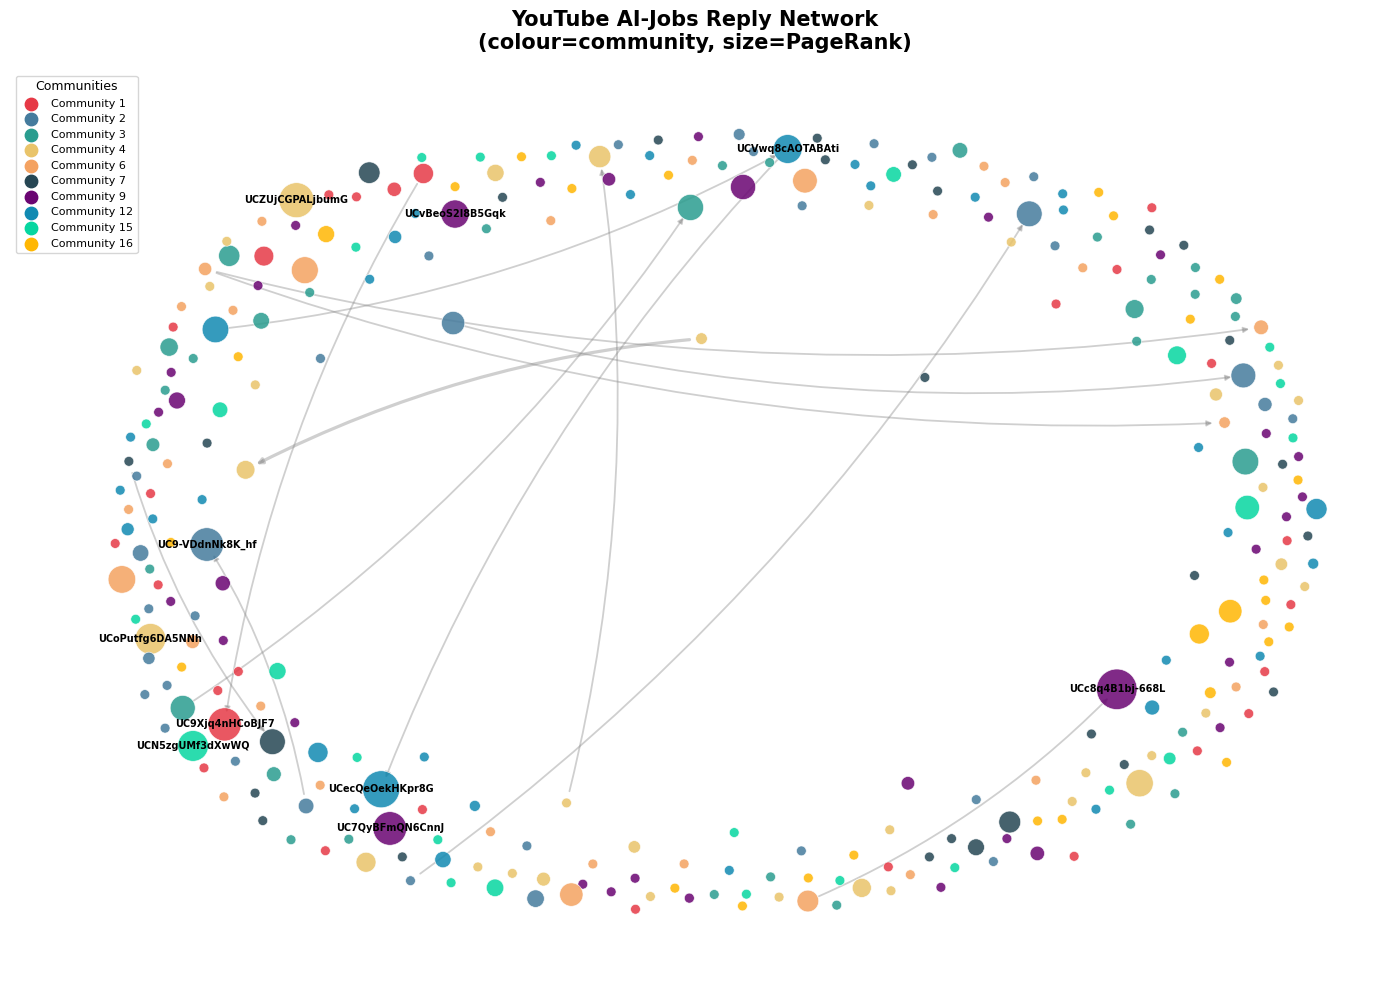

   Saved: outputs\fig5_network_bluesky.png


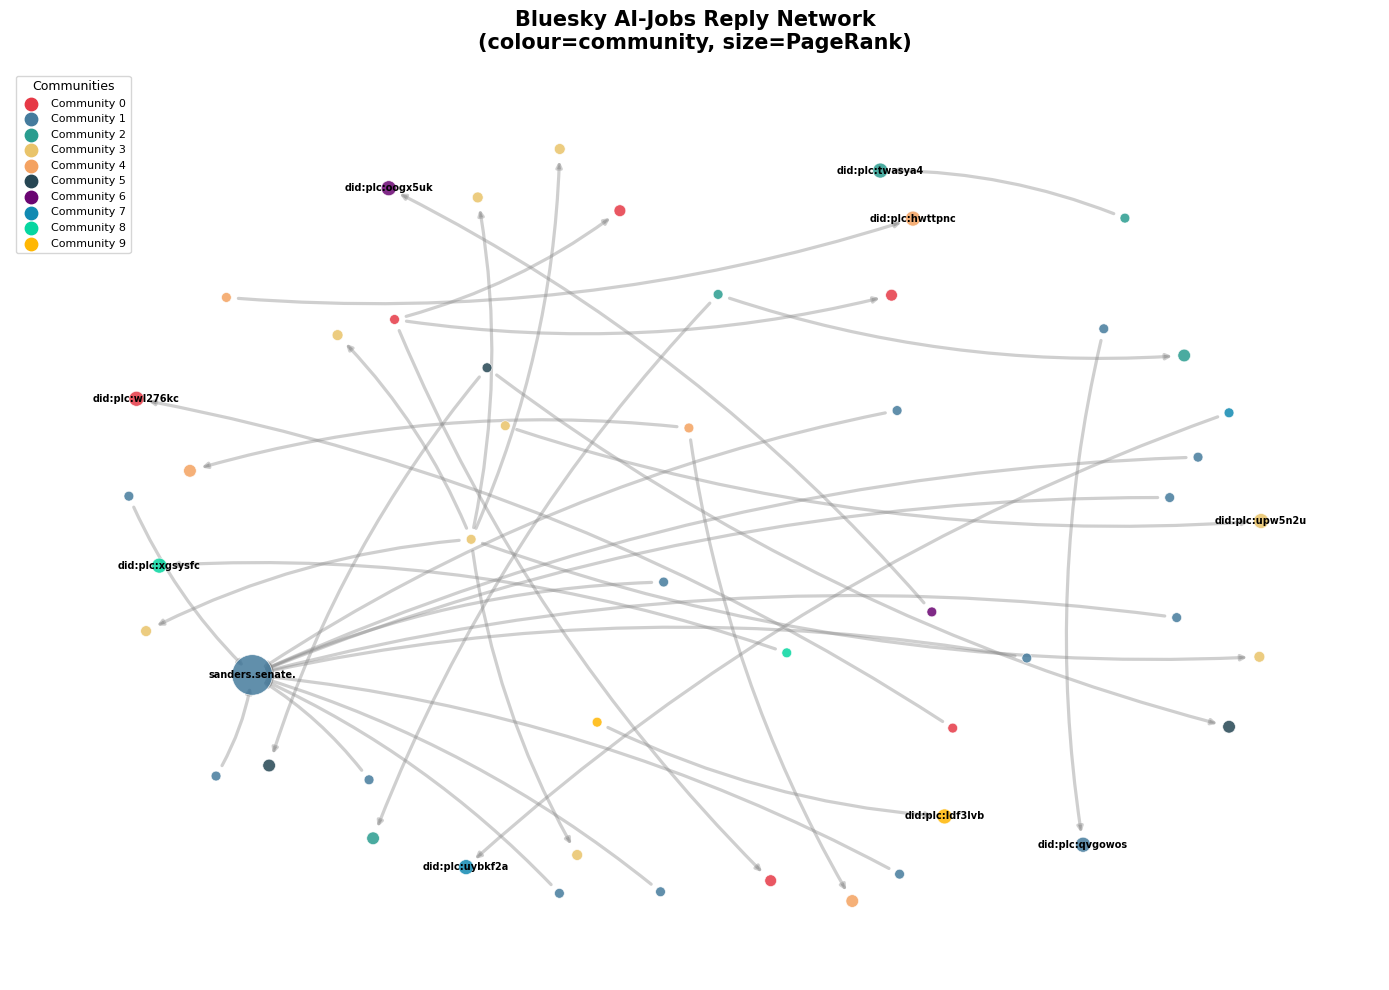

In [ ]:
#  Network Visualisation 
from network_analysis.visualiser import visualise_network

visualise_network(G_yt, partition_yt, df_cent_yt,
                  title='YouTube AI-Jobs Reply Network\n(colour=community, size=PageRank)',
                  save_path=os.path.join(OUTPUT_DIR,'fig4_network_youtube.png'))

visualise_network(G_bsky, partition_bsky, df_cent_bsky,
                  title='Bluesky AI-Jobs Reply Network\n(colour=community, size=PageRank)',
                  save_path=os.path.join(OUTPUT_DIR,'fig5_network_bluesky.png'))

   Cross-community polarisation index (σ of means): 0.1819


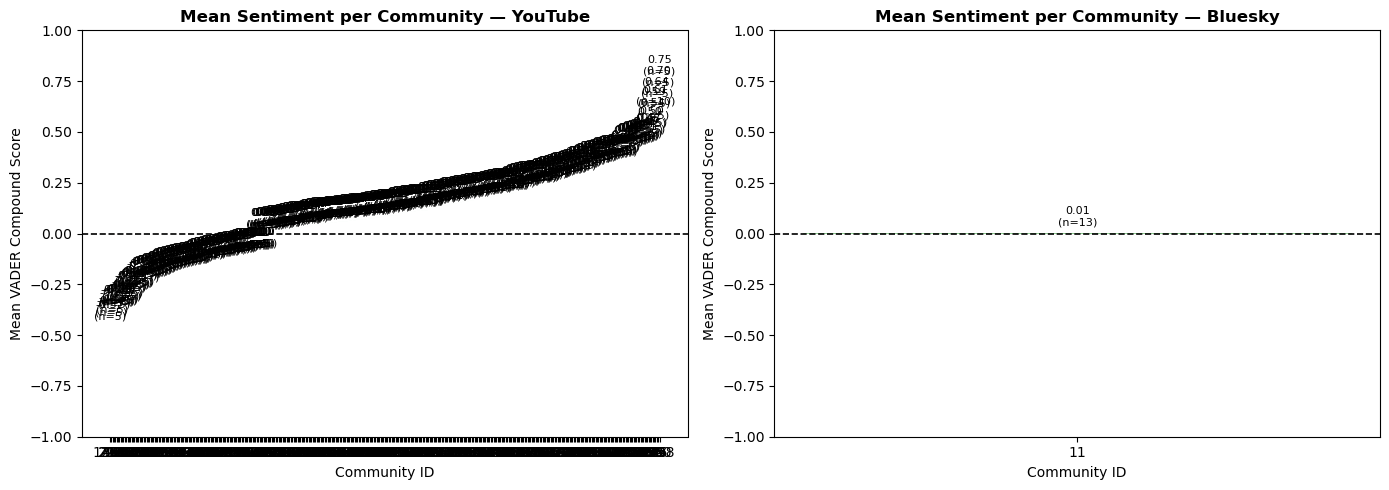


=== YouTube Community Sentiment Table ===
 community  n_users  n_posts  mean_sentiment  std_sentiment  pct_positive  pct_negative  pct_neutral sentiment_label
         1        5        5          0.0000         0.0000         0.000         0.000        1.000         Neutral
         2        5        5         -0.0110         0.3179         0.200         0.200        0.600         Neutral
         3        5        5          0.2793         0.3860         0.400         0.000        0.600        Positive
         4        5        5          0.4325         0.3144         0.800         0.000        0.200        Positive
         5        5        5          0.2343         0.2251         0.600         0.000        0.400        Positive
         6        5        5          0.3038         0.5987         0.600         0.200        0.200        Positive
         7        5        5         -0.0068         0.2541         0.200         0.400        0.400         Neutral
         9        5  

In [ ]:
#  Community Sentiment — is there polarisation? 
from network_analysis.community_sentiment import analyse_community_sentiment

df_comm_sent_yt = analyse_community_sentiment(
    df_yt_comments, df_cent_yt, partition_yt,
    user_col='author_id', sentiment_col='compound')

df_comm_sent_bsky = analyse_community_sentiment(
    df_bsky, df_cent_bsky, partition_bsky,
    user_col='author_handle', sentiment_col='compound')

# Plot community sentiment bars
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df_cs, title) in zip(axes,[
        (df_comm_sent_yt,'YouTube'),
        (df_comm_sent_bsky,'Bluesky')]):
    if df_cs.empty:
        ax.text(0.5,0.5,'Insufficient data',ha='center',va='center'); continue
    df_s = df_cs.sort_values('mean_sentiment')
    bar_colors = ['#F44336' if v<0 else '#4CAF50' for v in df_s['mean_sentiment']]
    bars = ax.bar(df_s['community'].astype(str), df_s['mean_sentiment'],
                  color=bar_colors, edgecolor='white', width=0.6)
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_title(f'Mean Sentiment per Community — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Community ID'); ax.set_ylabel('Mean VADER Compound Score')
    ax.set_ylim(-1, 1)
    for bar, row in zip(bars, df_s.itertuples()):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + (0.03 if row.mean_sentiment>=0 else -0.06),
                f'{row.mean_sentiment:.2f}\n(n={row.n_users})',
                ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig6_community_sentiment.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n=== YouTube Community Sentiment Table ===')
print(df_comm_sent_yt.to_string(index=False))
print('\n=== Bluesky Community Sentiment Table ===')
print(df_comm_sent_bsky.to_string(index=False))

## STEP 6 — Answering the Research Question
### Q1: Do polarized emotional communities form? (YES / NO)
### Q2: Who are the top influential users?

In [ ]:

# These non-parametric tests do not assume normal distribution,
# which is appropriate for VADER compound scores.
from scipy import stats as scipy_stats

if 'community' in df_cent_yt.columns:
    uid_comm_yt = dict(zip(df_cent_yt['node'], df_cent_yt['community']))
    df_yt_comments['community'] = df_yt_comments['author_id'].map(uid_comm_yt)
if 'community' in df_cent_bsky.columns:
    uid_comm_bsky = dict(zip(df_cent_bsky['node'], df_cent_bsky['community']))
    df_bsky['community'] = df_bsky['author_handle'].map(uid_comm_bsky)

print('=' * 65)
print('RESEARCH QUESTION ANSWER')
print('=' * 65)

def test_polarisation(df_comm_sent, df_posts, platform):
    print(f'\n-- {platform} --')
    if df_comm_sent.empty or len(df_comm_sent) < 2:
        print('  Not enough communities to test.')
        return False

    comm_means = df_comm_sent['mean_sentiment'].values
    spread = float(comm_means.std())
    print(f'Communities: {len(df_comm_sent)}')
    print(f'Sentiment range: {comm_means.min():.3f} to {comm_means.max():.3f}')
    print(f'Cross-community sigma: {spread:.4f}')

    # Kruskal-Wallis across all communities
    p_kw = 1.0
    p_mw = 1.0
    if 'community' in df_posts.columns:
        groups = []
        for cid in df_comm_sent['community']:
            g = df_posts[df_posts['community'] == cid]['compound'].dropna().tolist()
            if len(g) >= 3:
                groups.append(g)
        if len(groups) >= 2:
            h, p_kw = scipy_stats.kruskal(*groups)
            print(f'\n  Kruskal-Wallis (all communities):')
            print(f'H = {h:.4f},  p = {p_kw:.4f}')
            sig = 'SIGNIFICANT' if p_kw < 0.05 else 'not significant'
            print(f'-> {sig} difference in sentiment across communities (alpha=0.05)')

            # Mann-Whitney pairwise: most positive vs most negative community
            pos_id = df_comm_sent.loc[df_comm_sent['mean_sentiment'].idxmax(), 'community']
            neg_id = df_comm_sent.loc[df_comm_sent['mean_sentiment'].idxmin(), 'community']
            if pos_id != neg_id:
                g_pos = df_posts[df_posts['community'] == pos_id]['compound'].dropna()
                g_neg = df_posts[df_posts['community'] == neg_id]['compound'].dropna()
                if len(g_pos) >= 3 and len(g_neg) >= 3:
                    u, p_mw = scipy_stats.mannwhitneyu(g_pos, g_neg, alternative='two-sided')
                    pos_m = df_comm_sent[df_comm_sent['community']==pos_id]['mean_sentiment'].values[0]
                    neg_m = df_comm_sent[df_comm_sent['community']==neg_id]['mean_sentiment'].values[0]
                    print(f'\n  Mann-Whitney U (most positive comm {pos_id} mu={pos_m:.3f}')
                    print(f'vs most negative comm {neg_id} mu={neg_m:.3f}):')
                    print(f'U = {u:.1f},  p = {p_mw:.4f}')
                    sig2 = 'SIGNIFICANT' if p_mw < 0.05 else 'not significant'
                    print(f'-> {sig2} (alpha=0.05)')

    has_pos = any(df_comm_sent['sentiment_label'] == 'Positive')
    has_neg = any(df_comm_sent['sentiment_label'] == 'Negative')
    polarised = has_pos and has_neg and spread > 0.05 and p_kw < 0.05
    print()
    if polarised:
        print(f' ANSWER: YES - Polarised communities ARE present on {platform}')
        print(f' Statistically significant sentiment differences between communities detected.')
    else:
        print(f' ANSWER: NO - No statistically significant polarisation on {platform}')
    return polarised

polarised_yt   = test_polarisation(df_comm_sent_yt,   df_yt_comments, 'YouTube')
polarised_bsky = test_polarisation(df_comm_sent_bsky, df_bsky,        'Bluesky')


RESEARCH QUESTION ANSWER

-- YouTube --
Communities: 405
Sentiment range: -0.365 to 0.750
Cross-community sigma: 0.1817

  Kruskal-Wallis (all communities):
H = 632.3636,  p = 0.0000
-> SIGNIFICANT difference in sentiment across communities (alpha=0.05)

  Mann-Whitney U (most positive comm 350 mu=0.750
vs most negative comm 1205 mu=-0.365):
U = 30.0,  p = 0.0075
-> SIGNIFICANT (alpha=0.05)

 ANSWER: YES - Polarised communities ARE present on YouTube
 Statistically significant sentiment differences between communities detected.

-- Bluesky --
  Not enough communities to test.


In [ ]:
from network_analysis.influence_roles import classify_user_roles

df_roles_yt   = classify_user_roles(df_cent_yt)
df_roles_bsky = classify_user_roles(df_cent_bsky)

print('=' * 60)
print('TOP INFLUENTIAL USERS SHAPING COMMUNITIES')
print('=' * 60)

for platform, df_roles, df_comm in [
        ('YouTube', df_roles_yt, df_comm_sent_yt),
        ('Bluesky', df_roles_bsky, df_comm_sent_bsky)]:

    print(f'\n── {platform} TOP 10 INFLUENTIAL USERS ──')
    print(f'  (ranked by composite influence score)')
    print()

    if df_roles.empty:
        print('  No data.')
        continue

    # Merge in community sentiment label so we can show which community they're in
    if not df_comm.empty and 'community' in df_roles.columns:
        df_roles = df_roles.merge(
            df_comm[['community','sentiment_label']].rename(
                columns={'sentiment_label':'comm_sentiment'}),
            on='community', how='left')
    else:
        df_roles['comm_sentiment'] = 'N/A'

    top10 = df_roles.head(10)
    for rank, (_, row) in enumerate(top10.iterrows(), 1):
        comm_sent = row.get('comm_sentiment', 'N/A')
        print(f'  #{rank:2d}  {str(row["node"])[:35]:<35}'
              f'  Role={row["role"]:<10}'
              f'  PR={row["pagerank"]:.5f}'
              f'  Btw={row["betweenness"]:.4f}'
              f'  Community sentiment: {comm_sent}')

    # Save as table
    print()
    print(f'  Role breakdown:')
    for role, count in df_roles['role'].value_counts().items():
        print(f'    {role}: {count} users')

   User role distribution:
     Peripheral  : 7486
     Authority   : 2302
     Bridge      : 12
     Hub         : 8
   User role distribution:
     Hub         : 26
     Peripheral  : 24
     Authority   : 1
TOP INFLUENTIAL USERS SHAPING COMMUNITIES

── YouTube TOP 10 INFLUENTIAL USERS ──
  (ranked by composite influence score)

  # 1  UC_iEmYXdZJvjxdUMehwSXqw             Role=Hub         PR=0.00006  Btw=0.0000  Community sentiment: Positive
  # 2  UCdvk5SpMBvmeti1l-ROqxMA             Role=Bridge      PR=0.00026  Btw=0.0000  Community sentiment: Positive
  # 3  UCsDnfbANneHsk-TjjNJ2nEA             Role=Bridge      PR=0.00022  Btw=0.0000  Community sentiment: Positive
  # 4  UCUmYDiIQ6DXh2AlJxtR8ldg             Role=Authority   PR=0.00009  Btw=0.0000  Community sentiment: Positive
  # 5  UCojlzx8ssR9oHtJYIimWJcw             Role=Authority   PR=0.00012  Btw=0.0000  Community sentiment: Positive
  # 6  UCkOfEMUKI7fyiSd0BONX7KQ             Role=Authority   PR=0.00023  Btw=0.0000  Communi

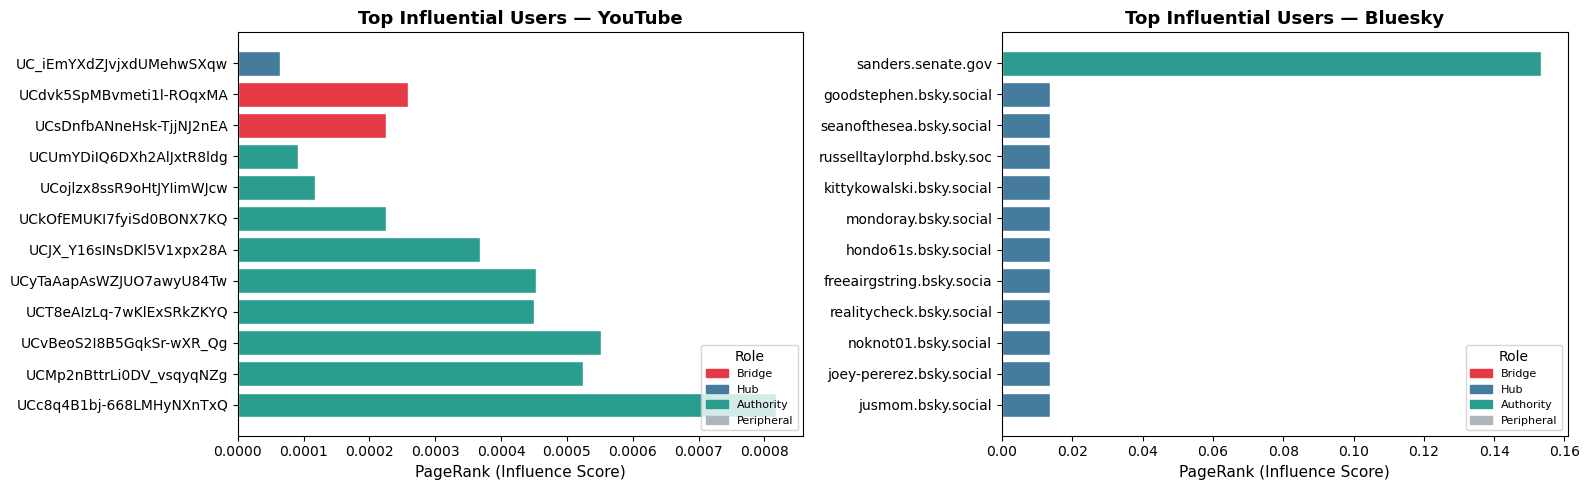

Saved: fig7_top_influencers.png


In [ ]:
# ─ Top influencers bar chart 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
role_colors = {'Bridge':'#E63946','Hub':'#457B9D','Authority':'#2A9D8F','Peripheral':'#ADB5BD'}

for ax, (df_r, title) in zip(axes,[
        (df_roles_yt,'YouTube'),
        (df_roles_bsky, 'Bluesky')]):
    if df_r.empty:
        ax.text(0.5,0.5,'No data',ha='center',va='center'); continue
    top = df_r.head(12)
    bar_colors = [role_colors.get(r,'grey') for r in top['role']]
    bars = ax.barh([str(n)[:25] for n in top['node']],top['pagerank'], color=bar_colors, edgecolor='white')
    ax.set_xlabel('PageRank (Influence Score)', fontsize=11)
    ax.set_title(f'Top Influential Users — {title}', fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    # Legend
    patches = [mpatches.Patch(color=c, label=r) for r,c in role_colors.items()]
    ax.legend(handles=patches, loc='lower right', fontsize=8, title='Role')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig7_top_influencers.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig7_top_influencers.png')

In [ ]:
# Diagnostic 
print("YouTube community column populated:", df_yt_comments['community'].notna().sum(), 
      "out of", len(df_yt_comments))
print("Topic column populated:", (df_yt_comments['yt_dominant_topic'] >= 0).sum())
print("Both populated:", df_yt_comments[
    df_yt_comments['community'].notna() & 
    (df_yt_comments['yt_dominant_topic'] >= 0)
].shape[0])

YouTube community column populated: 10079 out of 10100
Topic column populated: 9546
Both populated: 9526


In [ ]:
print("community dtype:", df_yt_comments['community'].dtype)
print("topic dtype:", df_yt_comments['yt_dominant_topic'].dtype)
print("community sample values:", df_yt_comments['community'].dropna().unique()[:10])
print("topic sample values:", df_yt_comments['yt_dominant_topic'].unique()[:10])

community dtype: float64
topic dtype: int64
community sample values: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
topic sample values: [ 1  3  0  4  2 -1]


Rows going into plot: 9526
Communities: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 96, 97, 98, 99, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 117, 118, 119, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 22

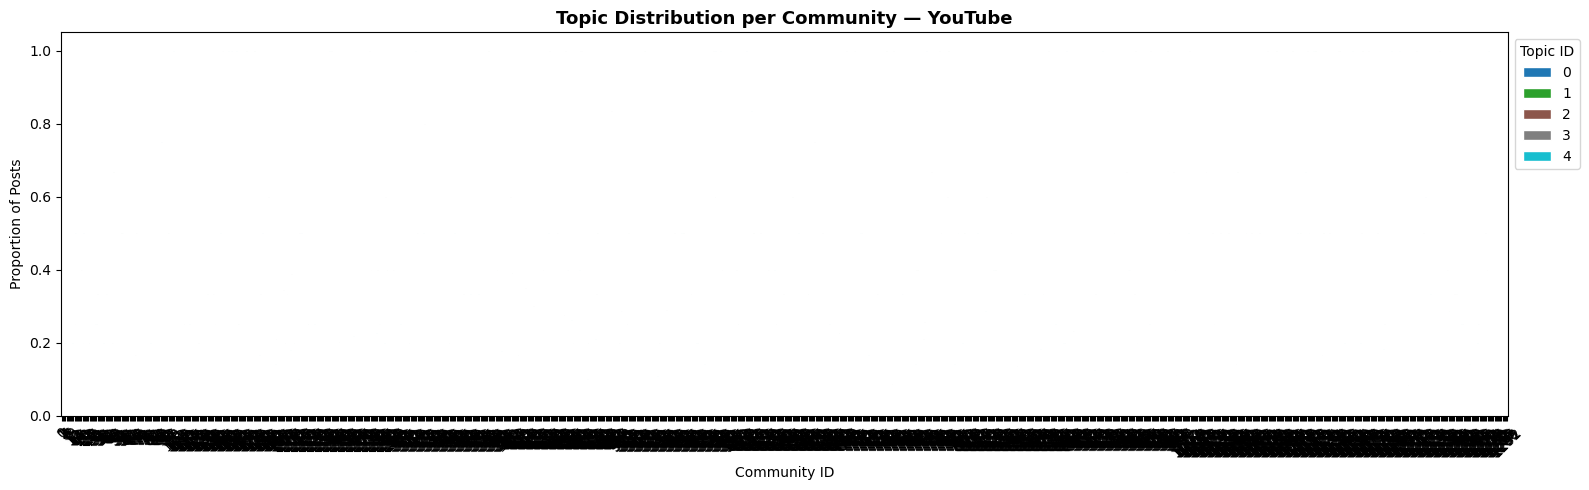

In [ ]:
df_yt_plot = df_yt_comments.copy()
df_yt_plot['community'] = df_yt_plot['community'].fillna(-1).astype(int)  # float → int
df_yt_plot['yt_dominant_topic'] = df_yt_plot['yt_dominant_topic'].astype(int)

valid = df_yt_plot[
    (df_yt_plot['community'] >= 0) &          # drop unassigned (-1)
    (df_yt_plot['yt_dominant_topic'] >= 0)    # drop LDA failures (-1)
]

print(f"Rows going into plot: {len(valid)}")  # should be ~8860
print(f"Communities: {sorted(valid['community'].unique())}")
print(f"Topics: {sorted(valid['yt_dominant_topic'].unique())}")

pivot = valid.groupby(['community', 'yt_dominant_topic']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(16, 5))
pivot_pct.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Topic Distribution per Community — YouTube', fontsize=13, fontweight='bold')
ax.set_xlabel('Community ID')
ax.set_ylabel('Proportion of Posts')
ax.legend(title='Topic ID', bbox_to_anchor=(1, 1))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_topic_per_community_youtube.png'), dpi=150, bbox_inches='tight')
plt.show()

Top 20 communities contain 3455 posts (36.3% of total)


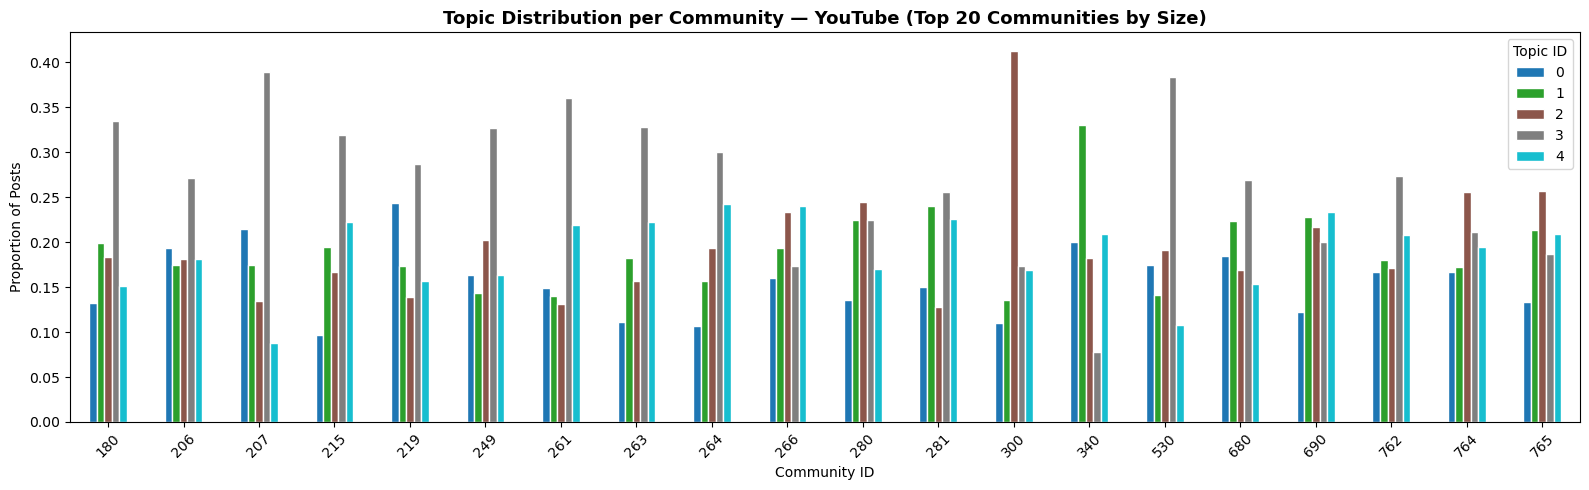


Top 20 community sizes:
community
300    515
180    283
762    218
263    200
765    190
690    185
764    183
206    164
249    157
280    156
266    154
215    149
340    143
264    140
207    137
281    137
680    133
530    125
219    119
261    117


In [ ]:
# Only keep the 20 largest communities for a readable plot
comm_sizes = df_yt_plot.groupby('community').size()
top20_comms = comm_sizes.nlargest(20).index.tolist()

valid_top20 = valid[valid['community'].isin(top20_comms)]
print(f"Top 20 communities contain {len(valid_top20)} posts ({len(valid_top20)/len(valid):.1%} of total)")

pivot = valid_top20.groupby(['community', 'yt_dominant_topic']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(16, 5))
pivot_pct.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Topic Distribution per Community — YouTube (Top 20 Communities by Size)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Community ID')
ax.set_ylabel('Proportion of Posts')
ax.legend(title='Topic ID', bbox_to_anchor=(1, 1))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_topic_per_community_youtube.png'), dpi=150, bbox_inches='tight')
plt.show()

# Also print the size of each top community
print("\nTop 20 community sizes:")
print(comm_sizes.nlargest(20).to_string())

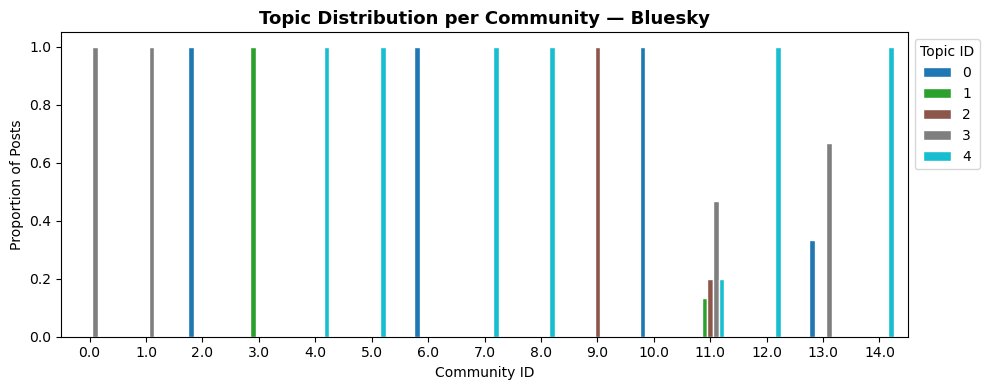

In [ ]:
#  Community × Topic Analysis: what does each community talk about? 
def community_topic_profile(df_posts, df_cent, topic_col, user_col, platform):
    """Show dominant topics per community."""
    if 'community' not in df_cent.columns or df_cent['community'].isna().all():
        return
    user_to_comm = dict(zip(df_cent['node'], df_cent['community']))
    df_posts = df_posts.copy()
    df_posts['community'] = df_posts[user_col].map(user_to_comm)
    valid = df_posts.dropna(subset=['community', topic_col])
    valid = valid[valid[topic_col] >= 0]
    if valid.empty:
        return

    pivot = valid.groupby(['community', topic_col]).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(10, 4))
    pivot_pct.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
    ax.set_title(f'Topic Distribution per Community — {platform}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Community ID'); ax.set_ylabel('Proportion of Posts')
    ax.legend(title='Topic ID', bbox_to_anchor=(1,1))
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'fig_topic_per_community_{platform.lower()}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

# community_topic_profile(df_yt_comments, df_cent_yt,   'yt_dominant_topic',   'author_id',     'YouTube')
community_topic_profile(df_bsky,        df_cent_bsky,  'bsky_dominant_topic', 'author_handle', 'Bluesky')

## STEP 7 — Network Statistics and Summary

In [ ]:
from network_analysis.stats import network_summary

summary_yt= network_summary(G_yt,'YouTube')
summary_bsky = network_summary(G_bsky, 'Bluesky')

df_summary = pd.DataFrame([summary_yt, summary_bsky])
print('=== NETWORK SUMMARY TABLE ===')
print(df_summary.T.to_string())
df_summary.to_csv(os.path.join(OUTPUT_DIR,'network_summary.csv'), index=False)

=== NETWORK SUMMARY TABLE ===
                                      0         1
platform                        YouTube   Bluesky
nodes                              9808        51
edges                              8830        36
density                        0.000092  0.014118
avg_clustering                   0.0022       0.0
avg_shortest_path               14.5439    1.8462
diameter                             51         2
reciprocity                      0.0002       0.0
avg_in_degree                       0.9     0.706
max_in_degree                        10        12
avg_out_degree                      0.9     0.706
n_weakly_connected_components      1257        15


## STEP 8 — Cross-Platform Comparisons

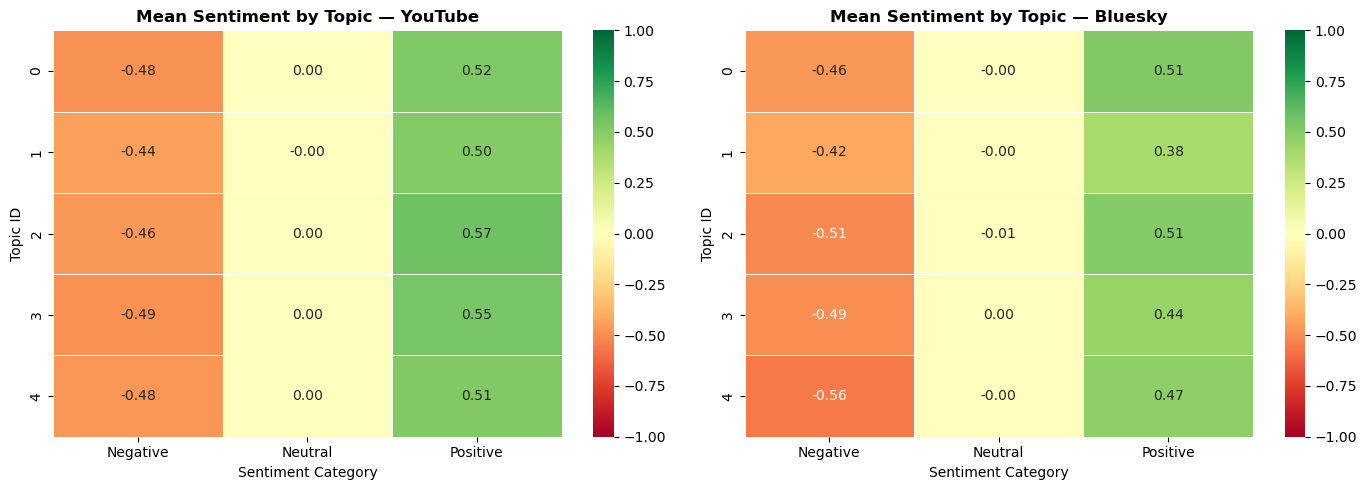


=== CROSS-PLATFORM POLARISATION COMPARISON ===
YouTube  — σ of community sentiments: 0.1819  (POLARISED)
Bluesky  — σ of community sentiments: nan  (NOT polarised)


In [ ]:
#  Heatmap: sentiment by topic per platform 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df, topic_col, title) in zip(axes,[
        (df_yt_comments, 'yt_dominant_topic',  'YouTube'),
        (df_bsky,'bsky_dominant_topic', 'Bluesky')]):
    valid = df[df[topic_col]>=0]
    if valid.empty:
        ax.text(0.5,0.5,'No data',ha='center',va='center'); continue
    pivot = valid.groupby([topic_col,'sentiment_label'])['compound'].mean().unstack(fill_value=0)
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, linewidths=0.5, vmin=-1, vmax=1)
    ax.set_title(f'Mean Sentiment by Topic — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sentiment Category'); ax.set_ylabel('Topic ID')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig8_sentiment_topic_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

#  Platform comparison summary 
print('\n=== CROSS-PLATFORM POLARISATION COMPARISON ===')
print(f'YouTube  — σ of community sentiments: '
      f'{df_comm_sent_yt["mean_sentiment"].std():.4f}  '
      f'({"POLARISED" if polarised_yt else "NOT polarised"})'  if not df_comm_sent_yt.empty else 'YouTube: no data')
print(f'Bluesky  — σ of community sentiments: '
      f'{df_comm_sent_bsky["mean_sentiment"].std():.4f}  '
      f'({"POLARISED" if polarised_bsky else "NOT polarised"})' if not df_comm_sent_bsky.empty else 'Bluesky: no data')

## STEP 9 — Saving All Outputs

In [ ]:
# Save all analysed DataFrames
df_yt_comments.to_csv(os.path.join(OUTPUT_DIR,'youtube_analysed.csv'), index=False)
df_bsky.to_csv(os.path.join(OUTPUT_DIR,'bluesky_analysed.csv'), index=False)
df_cent_yt.to_csv(os.path.join(OUTPUT_DIR,'centrality_youtube.csv'), index=False)
df_cent_bsky.to_csv(os.path.join(OUTPUT_DIR,'centrality_bluesky.csv'), index=False)
df_roles_yt.to_csv(os.path.join(OUTPUT_DIR,'roles_youtube.csv'), index=False)
df_roles_bsky.to_csv(os.path.join(OUTPUT_DIR,'roles_bluesky.csv'), index=False)
df_comm_sent_yt.to_csv(os.path.join(OUTPUT_DIR,'community_sentiment_youtube.csv'), index=False)
df_comm_sent_bsky.to_csv(os.path.join(OUTPUT_DIR,'community_sentiment_bluesky.csv'), index=False)

print(' All outputs saved to outputs/')
print()
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR,f))
    print(f'  {f:<50} {size/1024:.1f} KB')

 All outputs saved to outputs/

  bluesky_analysed.csv                               614.1 KB
  centrality_bluesky.csv                             6.9 KB
  centrality_scatter.png                             100.4 KB
  centrality_youtube.csv                             1464.9 KB
  community_sentiment.png                            49.5 KB
  community_sentiment_bluesky.csv                    0.2 KB
  community_sentiment_youtube.csv                    18.3 KB
  fig1_sentiment_distribution.png                    42.2 KB
  fig2_topic_distribution.png                        35.9 KB
  fig3_centrality_scatter.png                        129.6 KB
  fig4_network_youtube.png                           343.0 KB
  fig5_network_bluesky.png                           325.6 KB
  fig6_community_sentiment.png                       111.3 KB
  fig7_top_influencers.png                           169.8 KB
  fig8_sentiment_topic_heatmap.png                   77.0 KB
  fig_topic_per_community_bluesky.png         

## STEP 10 — Final Summary 


In [ ]:
print('=' * 65)
print('FINAL ANALYSIS SUMMARY — AI Job Replacement Discussion Study')
print('=' * 65)

print('\nNETWORK DESIGN')
print('  Nodes : Individual users (YouTube channel IDs / Bluesky handles)')
print('  Edges : Directed reply relationships (A → B = A replied to B)')
print('  Type  : Directed, weighted (weight = number of replies)')
print('  Why directed: replies have a clear sender/receiver')
print('  Why weighted: repeated replies = stronger interaction signal')

print('\nDATA COLLECTED')
print(f'  YouTube : {len(df_yt_comments):,} comments across {len(df_yt_videos):,} videos')
print(f'  Bluesky : {len(df_bsky):,} posts')

print('\nNLP ANALYSIS')
for platform, df in [('YouTube', df_yt_comments), ('Bluesky', df_bsky)]:
    pos = (df['sentiment_label']=='Positive').mean()
    neg = (df['sentiment_label']=='Negative').mean()
    print(f'  {platform}: {pos:.0%} positive, {neg:.0%} negative  σ={df["compound"].std():.3f}')

print('\nNETWORK ANALYSIS')
for label, G, n_comm in [
        ('YouTube', G_yt, len(set(partition_yt.values())) if partition_yt else 0),
        ('Bluesky', G_bsky, len(set(partition_bsky.values())) if partition_bsky else 0)]:
    print(f'  {label}: {G.number_of_nodes()} users, {G.number_of_edges()} reply edges, {n_comm} communities')

print('\nRESEARCH QUESTION ANSWERS')
print(f'  Q1 — Are communities polarised?')
print(f'       YouTube : {"YES" if polarised_yt else "NO"}')
print(f'       Bluesky : {"YES" if polarised_bsky else "NO"}')
print(f'  Q2 — Who are the top influential users?')
print(f'       See roles_youtube.csv and roles_bluesky.csv, and fig7_top_influencers.png')
if not df_roles_yt.empty:
    top3 = df_roles_yt.head(3)
    for _, r in top3.iterrows():
        print(f'       YouTube #{_+1}: {r["node"]} ({r["role"]})')
if not df_roles_bsky.empty:
    top3 = df_roles_bsky.head(3)
    for _, r in top3.iterrows():
        print(f'       Bluesky #{_+1}: {r["node"]} ({r["role"]})')

FINAL ANALYSIS SUMMARY — AI Job Replacement Discussion Study

NETWORK DESIGN
  Nodes : Individual users (YouTube channel IDs / Bluesky handles)
  Edges : Directed reply relationships (A → B = A replied to B)
  Type  : Directed, weighted (weight = number of replies)
  Why directed: replies have a clear sender/receiver
  Why weighted: repeated replies = stronger interaction signal

DATA COLLECTED
  YouTube : 10,100 comments across 77 videos
  Bluesky : 873 posts

NLP ANALYSIS
  YouTube: 45% positive, 26% negative  σ=0.461
  Bluesky: 38% positive, 50% negative  σ=0.513

NETWORK ANALYSIS
  YouTube: 9808 users, 8830 reply edges, 1293 communities
  Bluesky: 51 users, 36 reply edges, 15 communities

RESEARCH QUESTION ANSWERS
  Q1 — Are communities polarised?
       YouTube : YES
       Bluesky : NO
  Q2 — Who are the top influential users?
       See roles_youtube.csv and roles_bluesky.csv, and fig7_top_influencers.png
       YouTube #5502: UC_iEmYXdZJvjxdUMehwSXqw (Hub)
       YouTube #7031: